In [2]:
pip install joypy

Note: you may need to restart the kernel to use updated packages.


           日期  月份      PM2.5
0  2023-01-01  一月  74.831059
1  2023-01-02  一月  55.208015
2  2023-01-03  一月  79.662130
3  2023-01-04  一月  92.149763
4  2023-01-05  一月  83.160217


<Figure size 1200x800 with 0 Axes>

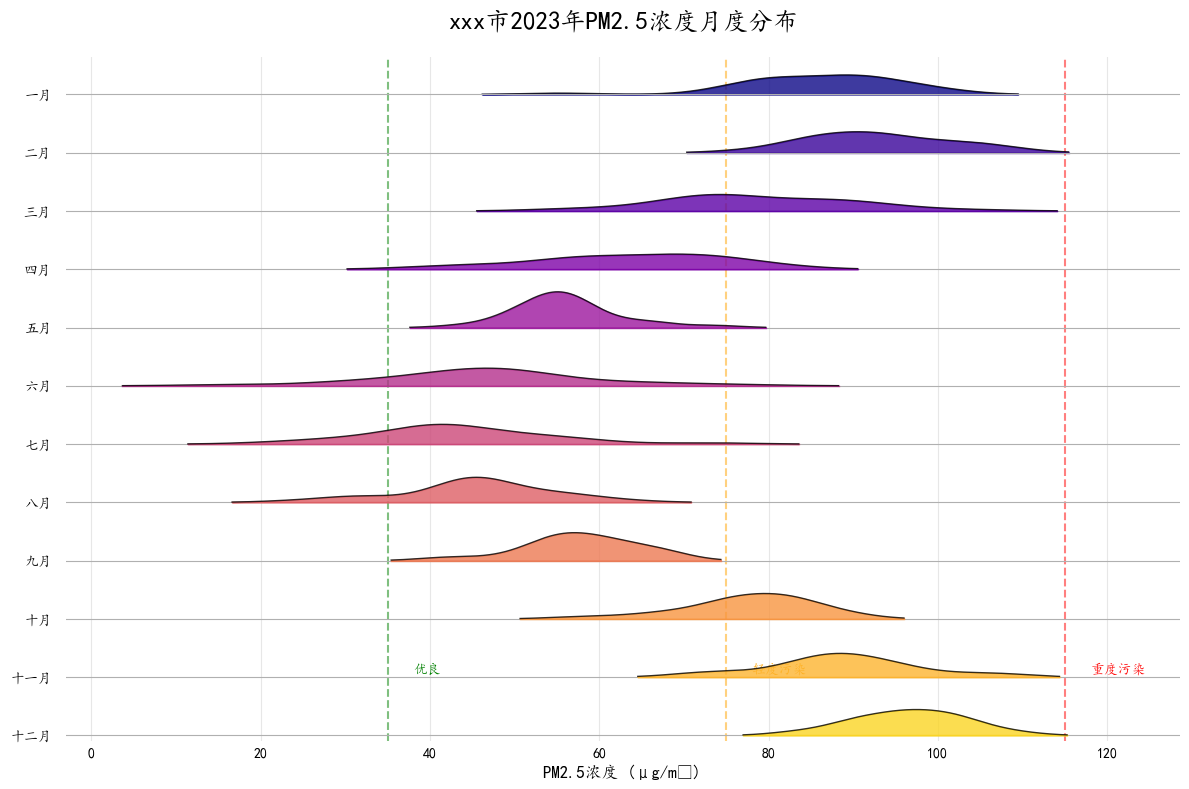

In [20]:
# 基础库导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import date, timedelta
from joypy import joyplot  # 山脊图绘制库
from pandas.api.types import CategoricalDtype
import matplotlib.font_manager as fm

# 设置中文字体（确保路径正确）
font_path = r'../simkai.ttf'  # 楷体字体文件路径
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
warnings.filterwarnings("ignore")  # 忽略警告信息

# ==================== 数据配置 ====================
# 各月PM2.5基准值（单位：μg/m³）
monthly_pm25 = {
    '北京': [85, 92, 78, 65, 55, 48, 42, 45, 60, 75, 88, 95],
    '上海': [72, 80, 65, 58, 45, 38, 35, 40, 55, 68, 75, 82],
    '广州': [60, 65, 58, 52, 45, 40, 38, 42, 50, 58, 65, 70]
}

# 污染波动范围（标准差）
pollution_std = [5, 8, 12]  # 轻度/中度/重度波动

# 月份列表（确保顺序正确）
months = ['一月', '二月', '三月', '四月', '五月', '六月', 
          '七月', '八月', '九月', '十月', '十一月', '十二月']

# ==================== 数据生成函数 ====================
def generate_air_quality_data(city_name):
    """生成模拟空气质量数据
    参数:
        city_name: 城市名称（必须是monthly_pm25中的键）
    返回:
        DataFrame包含日期、月份、PM2.5浓度数据
    """
    data_records = []
    current_date = date(2023, 1, 1)
    end_date = date(2023, 12, 31)
    
    while current_date <= end_date:
        month_idx = current_date.month - 1
        base_pm25 = monthly_pm25[city_name][month_idx]
        
        # 生成随机PM2.5值（正态分布）
        daily_pm25 = np.random.normal(
            loc=base_pm25,
            scale=pollution_std[np.random.randint(0, 3)]  # 随机选择波动程度
        )
        
        data_records.append({
            '日期': current_date,
            '月份': months[month_idx],
            'PM2.5': max(10, daily_pm25)  # 确保最小值不低于10
        })
        current_date += timedelta(days=1)
    
    # 转换为DataFrame并设置月份为有序类别
    df = pd.DataFrame(data_records)
    df['月份'] = df['月份'].astype(CategoricalDtype(months, ordered=True))
    return df

# ==================== 可视化函数 ====================
def plot_air_quality(df, city_name):
    """绘制空气质量山脊图
    参数:
        df: 包含PM2.5和月份的数据框
        city_name: 城市名称（用于标题）
    """
    plt.figure(figsize=(12, 8))
    
    # 创建山脊图（joyplot）
    fig, axes = joyplot(
        data=df[['PM2.5', '月份']],
        by='月份',
        column='PM2.5',
        colormap=plt.cm.plasma,  # 使用等离子色系
        range_style='own',  # 每月份独立坐标范围
        grid=True,
        alpha=0.8,
        figsize=(12, 8),
        linewidth=1
    )
    
    # 添加图表装饰
    plt.title(f'{city_name}2023年PM2.5浓度月度分布', 
              fontsize=18, pad=20)
    plt.xlabel('PM2.5浓度 (μg/m³)', fontsize=12)
    plt.ylabel('概率密度', fontsize=12)
    
    # 添加空气质量标准参考线
    plt.axvline(x=35, color='green', linestyle='--', alpha=0.5)
    plt.axvline(x=75, color='orange', linestyle='--', alpha=0.5)
    plt.axvline(x=115, color='red', linestyle='--', alpha=0.5)
    
    # 添加图例说明
    plt.text(38, 0.1, '优良', color='green', fontsize=10)
    plt.text(78, 0.1, '轻度污染', color='orange', fontsize=10)
    plt.text(118, 0.1, '重度污染', color='red', fontsize=10)
    
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('山峦图_pm2.5.png', dpi=400, bbox_inches='tight')
    plt.show()

# ==================== 主执行流程 ====================
if __name__ == "__main__":
    # 生成北京空气质量数据
    beijing_df = generate_air_quality_data('北京')
    print(beijing_df.head())  # 打印前5行数据示例
    
    # 绘制可视化图表
    plot_air_quality(beijing_df, 'xxx市')

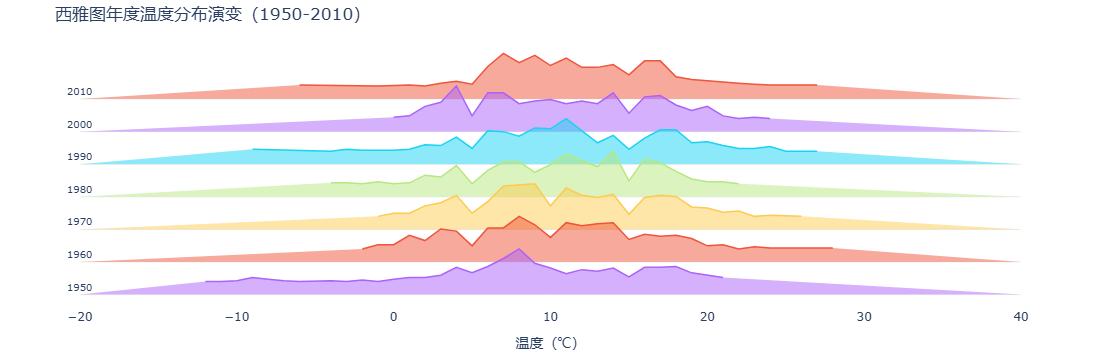

In [21]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def load_and_filter_data(file_path):
    """
    加载并预处理天气数据
    :param file_path: CSV文件路径
    :return: 处理后的DataFrame
    """
    # 读取原始数据集
    raw_data = pd.read_csv(file_path)
    
    # 转换日期格式并提取年份
    raw_data['record_year'] = pd.to_datetime(raw_data['Date']).dt.year
    
    # 筛选指定年份的数据（硬编码简化示例，实际建议参数化）
    selected_years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
    filtered_data = raw_data[raw_data['record_year'].isin(selected_years)]
    
    return filtered_data

def calculate_temp_distribution(weather_df):
    """
    计算温度分布频率
    :param weather_df: 预处理后的天气数据
    :return: 包含温度分布的DataFrame
    """
    # 按年份和温度分组统计频次
    temp_freq = weather_df.groupby(['record_year', 'Mean_TemperatureC']).agg(
        day_count=('Mean_TemperatureC', 'count')
    ).reset_index()
    
    return temp_freq

def normalize_scale(data_series):
    """
    数据归一化处理（最小-最大标准化）
    :param data_series: 需要标准化的数据序列
    :return: 标准化后的numpy数组
    """
    min_val = data_series.min()
    max_val = data_series.max()
    # 避免除零错误
    if max_val == min_val:
        return np.zeros_like(data_series)
    return (data_series - min_val) / (max_val - min_val)

def create_ridge_plot(temp_distribution, years):
    """
    创建山脊图可视化
    :param temp_distribution: 温度分布数据
    :param years: 需要展示的年份列表
    """
    # 初始化图表对象
    figure = go.Figure()
    
    # 预计算垂直偏移参数
    base_offset = len(years)
    vertical_gap = 0.4  # 设置层间间距
    
    # 按倒序创建各年份图层（保证最新的年份显示在最上方）
    for idx, year in enumerate(reversed(years)):
        # 当前年份数据筛选
        year_data = temp_distribution[temp_distribution['record_year'] == year]
        
        # 计算垂直位置参数
        vertical_pos = base_offset - idx
        y_offset = vertical_pos + vertical_gap
        
        # 添加背景参考线
        figure.add_trace(go.Scatter(
            x=[-20, 40], 
            y=np.full(2, vertical_pos),
            mode='lines',
            line=dict(color='rgba(200,200,200,0.3)', width=1)
        ))
        
        # 添加温度分布曲线
        figure.add_trace(go.Scatter(
            x=year_data['Mean_TemperatureC'],
            y=normalize_scale(year_data['day_count']) + y_offset,
            fill='tonexty',
            name=str(year),
            line=dict(width=1.5)
        ))
        
        # 添加年份标注
        figure.add_annotation(
            x=-20,
            y=vertical_pos,
            text=str(year),
            showarrow=False,
            font=dict(size=10),
            yshift=8
        )
    
    # 设置图表布局
    figure.update_layout(
        title='西雅图年度温度分布演变（1950-2010）',
        showlegend=False,
        xaxis=dict(title='温度（℃）', range=[-20, 40]),
        yaxis=dict(visible=False),
        plot_bgcolor='white',
        margin=dict(t=40, b=20)
    )
    
    return figure

# 主执行流程
if __name__ == "__main__":
    # 数据加载与处理
    processed_data = load_and_filter_data('2016-weather-data-seattle.csv')
    
    # 温度分布计算
    temp_distribution = calculate_temp_distribution(processed_data)
    
    # 生成可视化图表
    vis_figure = create_ridge_plot(temp_distribution, processed_data['record_year'].unique())
    
    # 显示结果
    vis_figure.show()


# 使用实线

<Figure size 1400x1200 with 0 Axes>

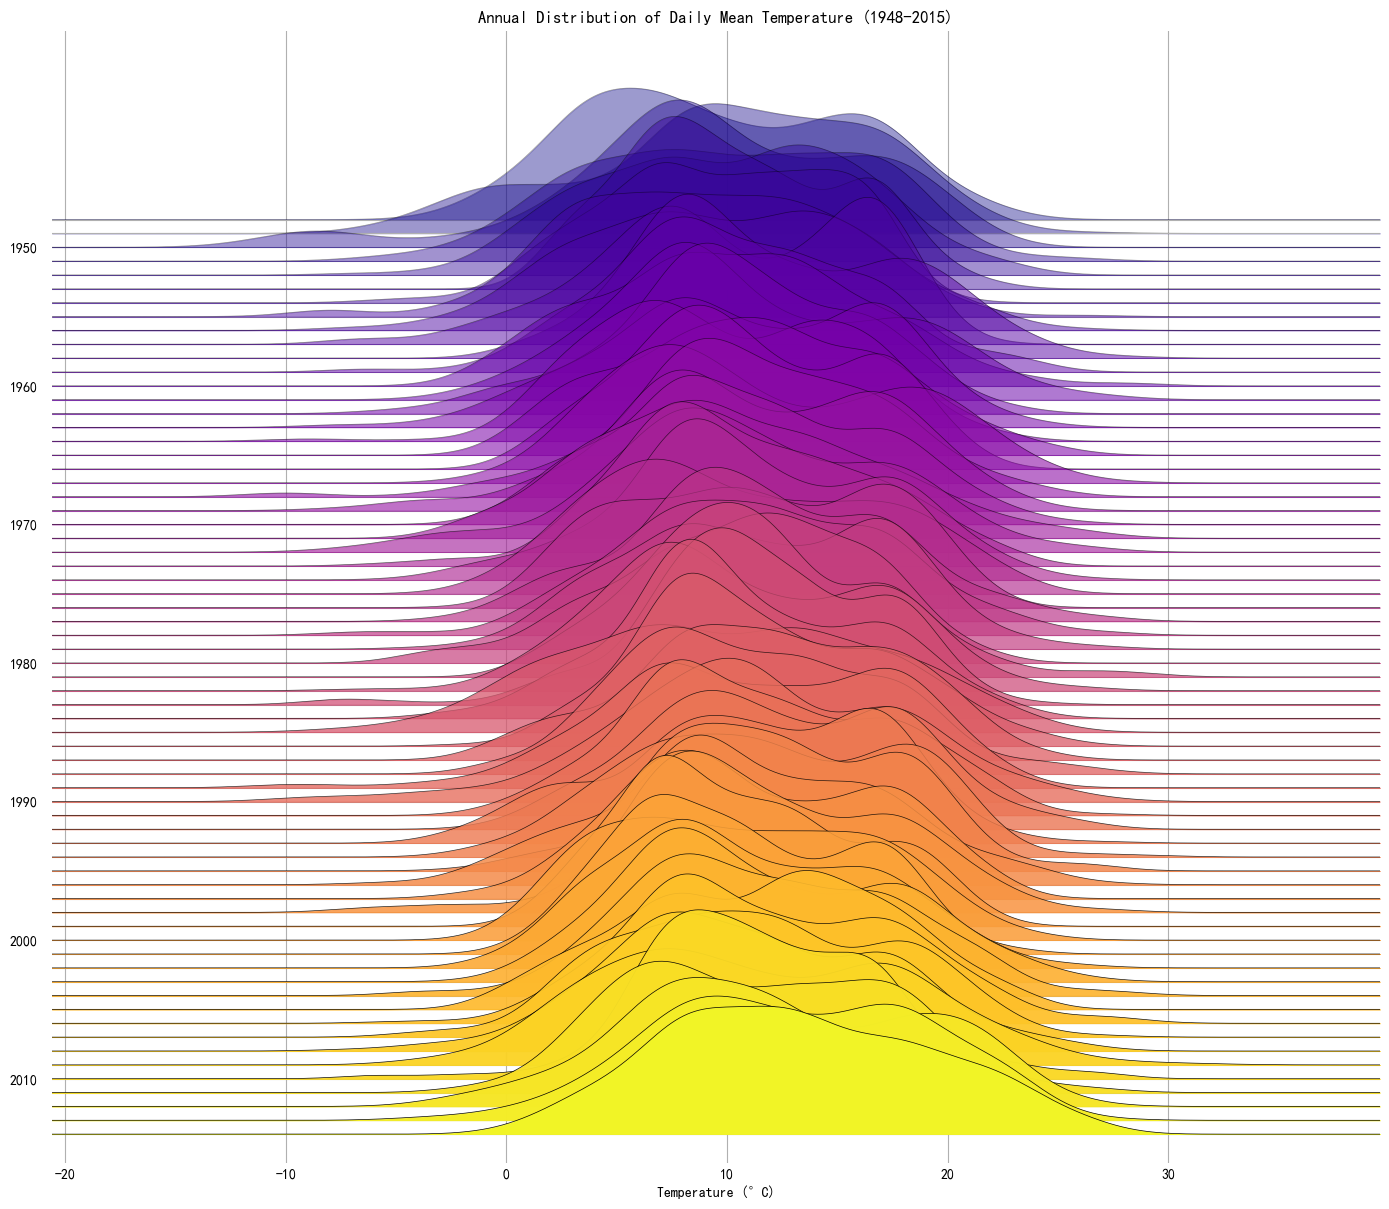

In [22]:
import pandas as pd
import joypy
import matplotlib.pyplot as plt

# 读取数据并处理日期
df = pd.read_csv('2016-weather-data-seattle.csv', parse_dates=['Date'])
df['Year'] = df['Date'].dt.year

# 生成每十年显示一次的标签
years = sorted(df['Year'].unique())
labels = [str(year) if year % 10 == 0 else '' for year in years]

# 调整绘图参数
plt.figure(figsize=(14, 12))

# 绘制山脊图（修正参数）
fig, axes = joypy.joyplot(
    df,
    by='Year',
    column='Mean_TemperatureC',
    labels=labels,
    overlap=3,
    linewidth=0.5,
    colormap=plt.cm.plasma,
    fade=True,
    figsize=(14, 12),
    title='Annual Distribution of Daily Mean Temperature (1948-2015)',
    grid=True
)

# 手动添加坐标轴标签
plt.xlabel('Temperature (°C)')  # 添加X轴标签
plt.ylabel('Year')              # 添加Y轴标签

# 优化Y轴刻度显示
start_year = 1948
end_year = 2015
plt.yticks(
    ticks=range(0, end_year-start_year+1, 10),
    labels=[str(start_year + i*10) for i in range((end_year - start_year)//10 + 1)]
)
plt.savefig('山峦图_每年气温分布.png', dpi=400, bbox_inches='tight')
plt.show()


# 使用虚线

<Figure size 1400x1200 with 0 Axes>

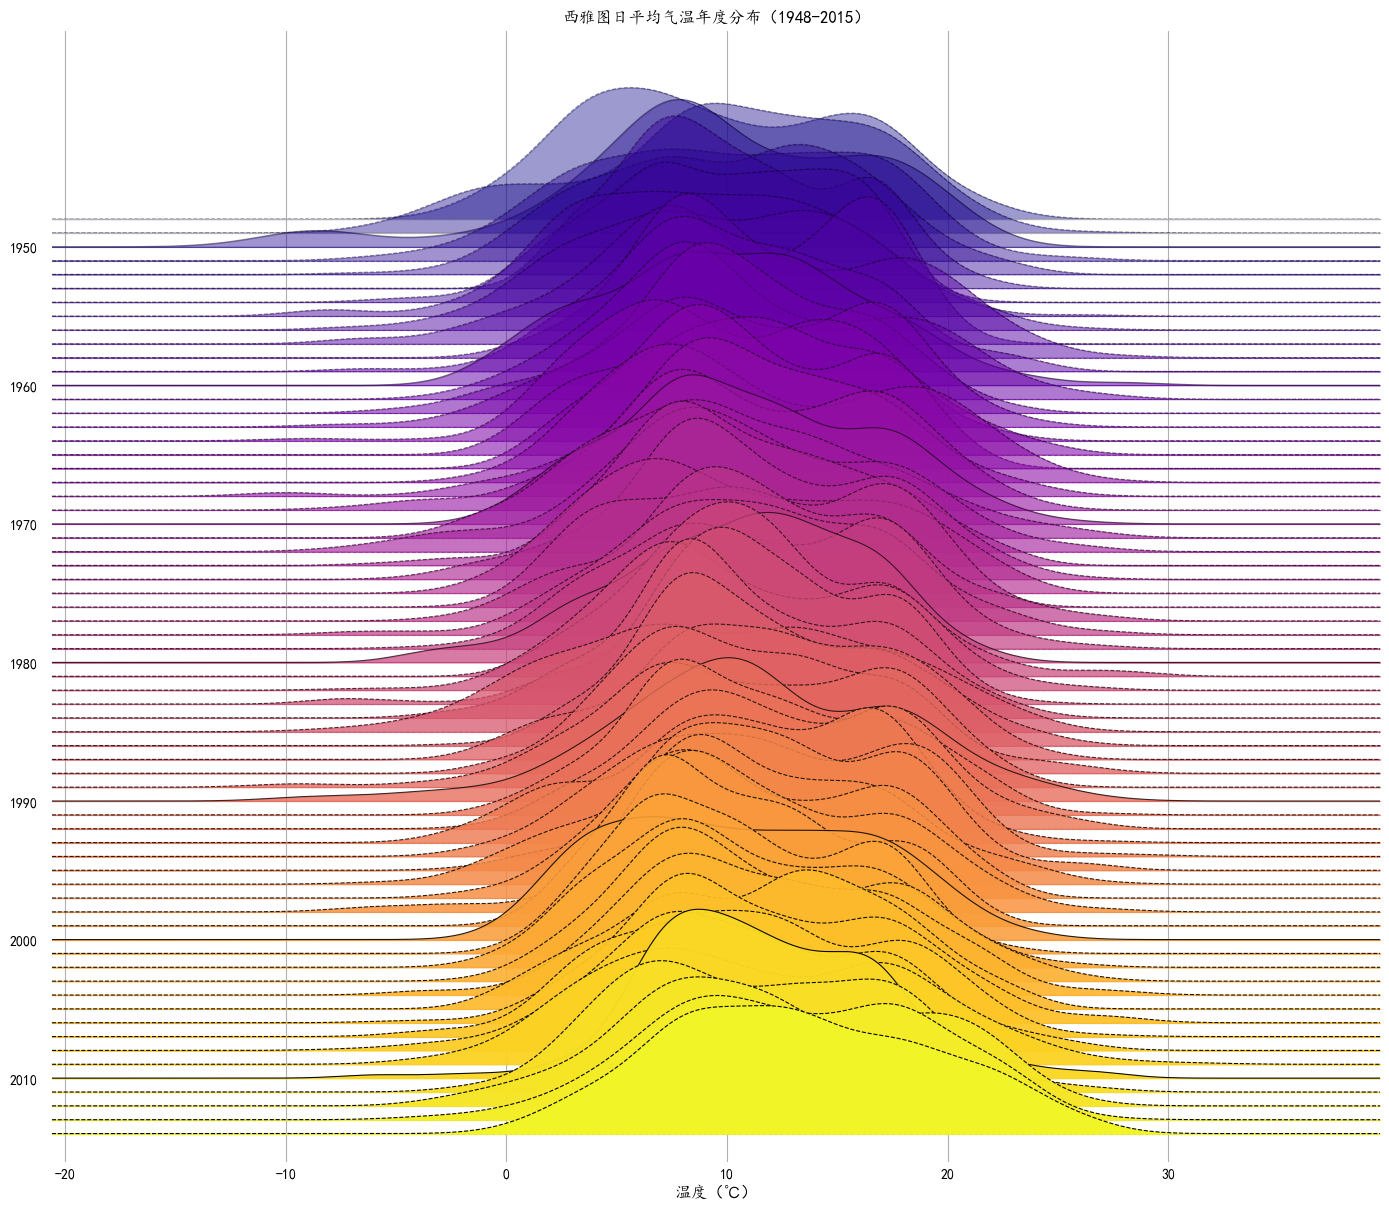

In [23]:
import pandas as pd
import joypy
import matplotlib.pyplot as plt
import numpy as np

# 数据加载与预处理
def load_process_data(file_path):
    """加载并处理天气数据"""
    df = pd.read_csv(file_path, parse_dates=['Date'])
    df['Year'] = df['Date'].dt.year
    return df[df['Year'].between(1948, 2015)]  # 确保年份在指定范围内

# 生成智能刻度标签
def generate_smart_labels(years):
    """生成每十年显示一次的标签"""
    return [str(y) if y % 10 == 0 else '' for y in years]

# 设置线型逻辑
def get_line_style(year):
    """根据年份返回对应线型"""
    return '-' if year % 10 == 0 else '--'

# 可视化配置
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False

# 主流程
if __name__ == "__main__":
    # 数据准备
    weather_df = load_process_data('2016-weather-data-seattle.csv')
    sorted_years = sorted(weather_df['Year'].unique())
    
    # 创建画布
    plt.figure(figsize=(14, 12))
    
    # 绘制山脊图
    fig, axes = joypy.joyplot(
        weather_df,
        by='Year',
        column='Mean_TemperatureC',
        labels=generate_smart_labels(sorted_years),
        overlap=3,
        linewidth=0.8,  # 适当加粗线宽
        colormap=plt.cm.plasma,
        fade=True,
        figsize=(14, 12),
        title='西雅图日平均气温年度分布（1948-2015）',
        grid=True
    )

    # 设置线型逻辑
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else axes
    for idx, ax in enumerate(axes_flat):
        if idx < len(sorted_years):  # 防止索引越界
            current_year = sorted_years[idx]
            # 设置线条样式
            for line in ax.get_lines():
                line.set_linestyle(get_line_style(current_year))

    # 坐标轴优化
    plt.xlabel('温度（℃）', fontsize=12)
    plt.ylabel('年份', fontsize=12)
    
    # 生成智能Y轴刻度（每十年）
    start, end = 1948, 2015
    plt.yticks(
        ticks=np.linspace(0, end-start, num=8),
        labels=[str(start + i*10) for i in range(8)]
    )

    # 保存并显示
    plt.savefig('temperature_ridge_plot.png', dpi=400, bbox_inches='tight')
    plt.show()


<Figure size 1400x1200 with 0 Axes>

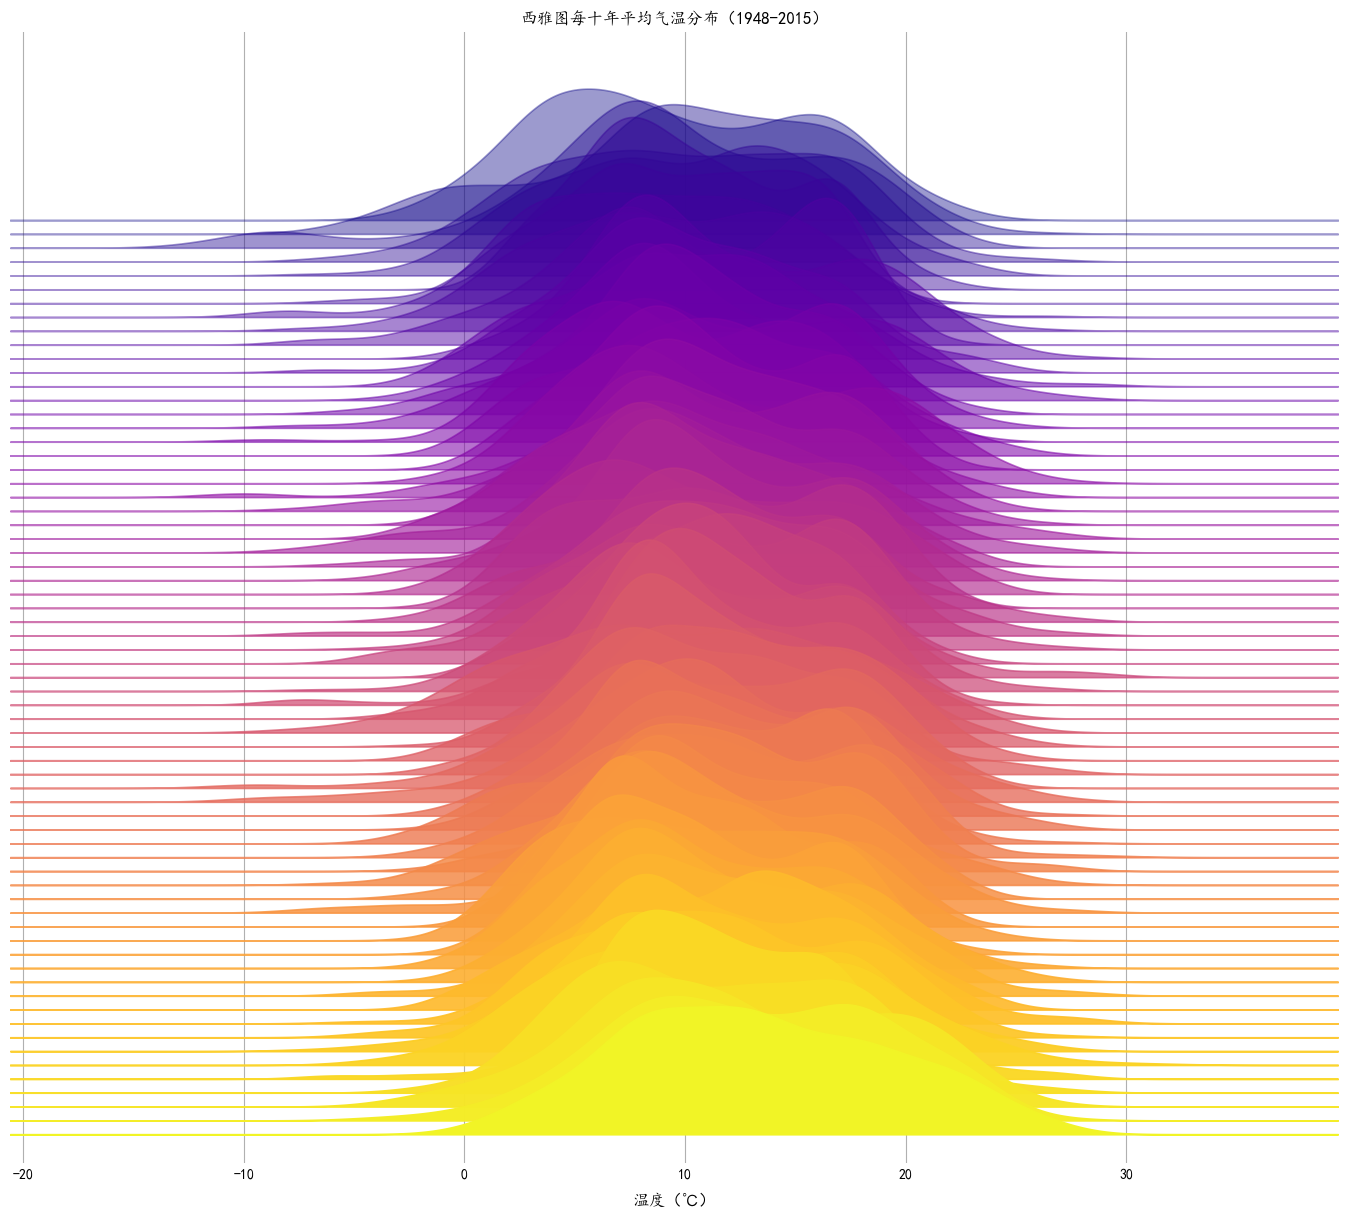

In [25]:
import pandas as pd
import joypy
import matplotlib.pyplot as plt
import numpy as np

def prepare_weather_data(file_path):
    """加载并预处理天气数据"""
    df = pd.read_csv(file_path, parse_dates=['Date'])
    df['Year'] = df['Date'].dt.year
    return df.query('Year >= 1948 and Year <= 2015')  # 确保数据范围

def configure_plot_styles():
    """配置全局绘图样式"""
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

def plot_decadal_distribution(df):
    """绘制十年间隔的山脊图"""
    # 生成年份标签（空字符串处理）
    all_years = sorted(df['Year'].unique())
    labels = [str(y) if y % 10 == 0 else '' for y in all_years]

    # 创建基础图表
    plt.figure(figsize=(14, 12))
    fig, axes = joypy.joyplot(
        df,
        by='Year',
        column='Mean_TemperatureC',
        labels=labels,
        overlap=3,
        linewidth=1.2,  # 加粗实线
        colormap=plt.cm.plasma,
        fade=True,
        figsize=(14, 12),
        title='西雅图每十年平均气温分布（1948-2015）',
        grid=True
    )

    # 隐藏非十年份的线条
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else axes
    for idx, ax in enumerate(axes_flat):
        if idx < len(all_years):
            current_year = all_years[idx]
            # 隐藏所有图形元素
            for artist in ax.get_children():
                if isinstance(artist, plt.Line2D):
                    artist.set_visible(False)
                # 隐藏坐标轴
            ax.axis('off')

    # 坐标轴标注
    plt.xlabel('温度（℃）', fontsize=12, labelpad=10)
    plt.ylabel('年份', fontsize=12, labelpad=15)

    # 优化Y轴刻度
    valid_years = [y for y in all_years if y % 10 == 0]
    plt.yticks(
        ticks=np.linspace(0, len(all_years)-1, len(valid_years)),
        labels=valid_years
    )

    return fig

# 主执行流程
if __name__ == "__main__":
    configure_plot_styles()
    weather_data = prepare_weather_data('2016-weather-data-seattle.csv')
    figure = plot_decadal_distribution(weather_data)
    plt.savefig('decadal_temperature_distribution.png', dpi=400, bbox_inches='tight')
    plt.show()

# 每十年绘制

<Figure size 1400x1200 with 0 Axes>

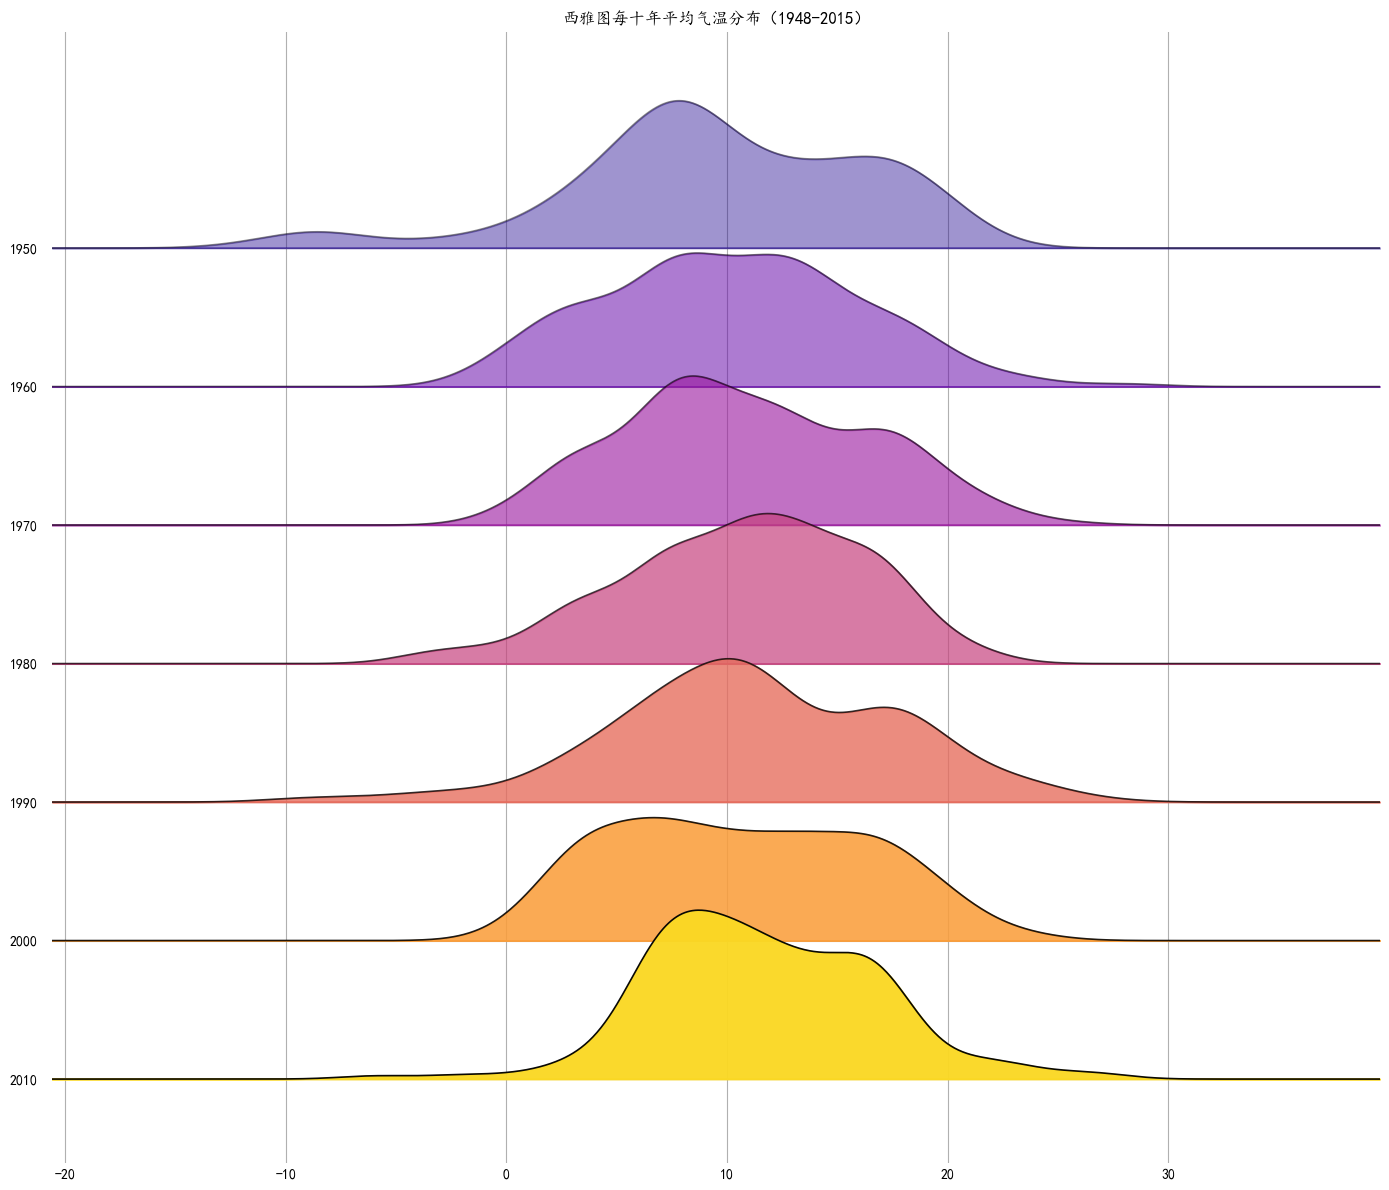

In [27]:
import pandas as pd
import joypy
import matplotlib.pyplot as plt
import numpy as np

def prepare_weather_data(file_path):
    """加载并预处理天气数据"""
    df = pd.read_csv(file_path, parse_dates=['Date'])
    df['Year'] = df['Date'].dt.year
    return df.query('Year >= 1948 and Year <= 2015')  # 保持原始数据范围不变

def configure_plot_styles():
    """配置全局绘图样式"""
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False

def plot_decadal_distribution(df):
    """绘制十年间隔的山脊图"""
    # 生成年份标签时添加筛选逻辑
    all_years = sorted(df['Year'].unique())
    
    # 关键修改：通过标签生成逻辑控制可见性
    labels = [str(y) if y % 10 == 0 else None for y in all_years]  # 非十年份设为None
    
    # 创建基础图表（保持参数不变）
    plt.figure(figsize=(14, 12))
    fig, axes = joypy.joyplot(
        df,
        by='Year',
        column='Mean_TemperatureC',
        labels=labels,          # 使用改进后的标签
        overlap=3,
        linewidth=1.2,
        colormap=plt.cm.plasma,
        fade=True,
        figsize=(14, 12),
        title='西雅图每十年平均气温分布（1948-2015）',
        grid=True
    )

    # 通过标签过滤实现自动隐藏
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else axes
    for idx, ax in enumerate(axes_flat):
        if idx < len(all_years):
            # 自动隐藏无标签的坐标轴
            if labels[idx] is None:
                ax.set_visible(False)  # 直接隐藏整个子图
            else:
                # 强化可见年份的坐标轴
                ax.spines['bottom'].set_visible(True)
                ax.spines['bottom'].set_linewidth(0.8)

    # 优化Y轴刻度
    valid_years = [y for y in all_years if y % 10 == 0]
    plt.yticks(
        ticks=np.linspace(0, len(all_years)-1, len(valid_years)),
        labels=valid_years
    )

    return fig

# 主执行流程
if __name__ == "__main__":
    configure_plot_styles()
    weather_data = prepare_weather_data('2016-weather-data-seattle.csv')
    figure = plot_decadal_distribution(weather_data)
    plt.savefig('decadal_temperature_distribution_1.png', dpi=400, bbox_inches='tight')
    plt.show()
